In [1]:
import pandas as pd
import numpy as np



In [2]:
df = pd.read_csv('powerplant_data.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# At -> Temperatur
# V -> Vacuum
# Ap -> Pressure
# Rh -> Humidity


# Pe -> Produced Energy



In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train


,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [11]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [12]:
df.shape

(9568, 5)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [15]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [16]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)



In [17]:
type(X_train_scaled)

numpy.ndarray

In [18]:
type(y_train)

pandas.Series

In [19]:
y_train.shape

(7654,)

In [20]:
y_train

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [21]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Deep Learning


In [23]:
# Build our Ann Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
        #1st hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            #2nd hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #Output Layer
            nn.Linear(6, 1),

    )

    def forward(self, x):
        return self.model(x)

In [24]:
import torch.optim as optim
model = ANN()

#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [25]:
epochs = 100
train_losses = []
val_losses = []

best_val_loss = float('inf')  # Initialize best validation loss to infinity

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for one epoch


    for xb, yb in train_loader:
        optimizer.zero_grad() # clear gradients for this batch

        outputs = model(xb) # forward propagation - predicted outputs for this batch
        loss = criterion(outputs, yb) #compute loss for this batch
        loss.backward() # backward propagation - compute gradients
        optimizer.step() # update weights

        running_loss += loss.item()  # accumulate loss for this batch loss is a tensor, so we use .item() to get the scalar py float value 
    epoch_loss = running_loss / len(train_loader) # average loss for this epoch
    train_losses.append(epoch_loss)


    model.eval() # set model to evaluation mode
    running_val_loss = 0.0

    with torch.no_grad(): # we don't need to compute gradients for validation

        for xb, yb in test_loader:

            outputs = model(xb) # forward propagation - predicted outputs for this batch
            loss = criterion(outputs, yb) #compute loss for this batch
            running_val_loss += loss.item()  # accumulate loss for this batch

    epoch_val_loss = running_val_loss / len(test_loader) # 
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {epoch_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pth')  # Save the model's state_dict





Epoch 1/100, Training Loss: 206483.9676, Validation Loss: 204971.6432
Epoch 2/100, Training Loss: 200501.9493, Validation Loss: 192637.6995
Epoch 3/100, Training Loss: 178943.0768, Validation Loss: 162144.0701
Epoch 4/100, Training Loss: 145166.7542, Validation Loss: 127858.9832
Epoch 5/100, Training Loss: 118374.5281, Validation Loss: 110312.7915
Epoch 6/100, Training Loss: 106832.0395, Validation Loss: 100434.8103
Epoch 7/100, Training Loss: 93098.9721, Validation Loss: 78609.2303
Epoch 8/100, Training Loss: 62566.8509, Validation Loss: 41745.1653
Epoch 9/100, Training Loss: 26629.9881, Validation Loss: 12750.4689
Epoch 10/100, Training Loss: 6921.2975, Validation Loss: 2994.7181
Epoch 11/100, Training Loss: 1918.3511, Validation Loss: 1321.6775
Epoch 12/100, Training Loss: 1040.6924, Validation Loss: 920.0537
Epoch 13/100, Training Loss: 752.0679, Validation Loss: 706.1089
Epoch 14/100, Training Loss: 580.8715, Validation Loss: 552.9809
Epoch 15/100, Training Loss: 455.1619, Validat

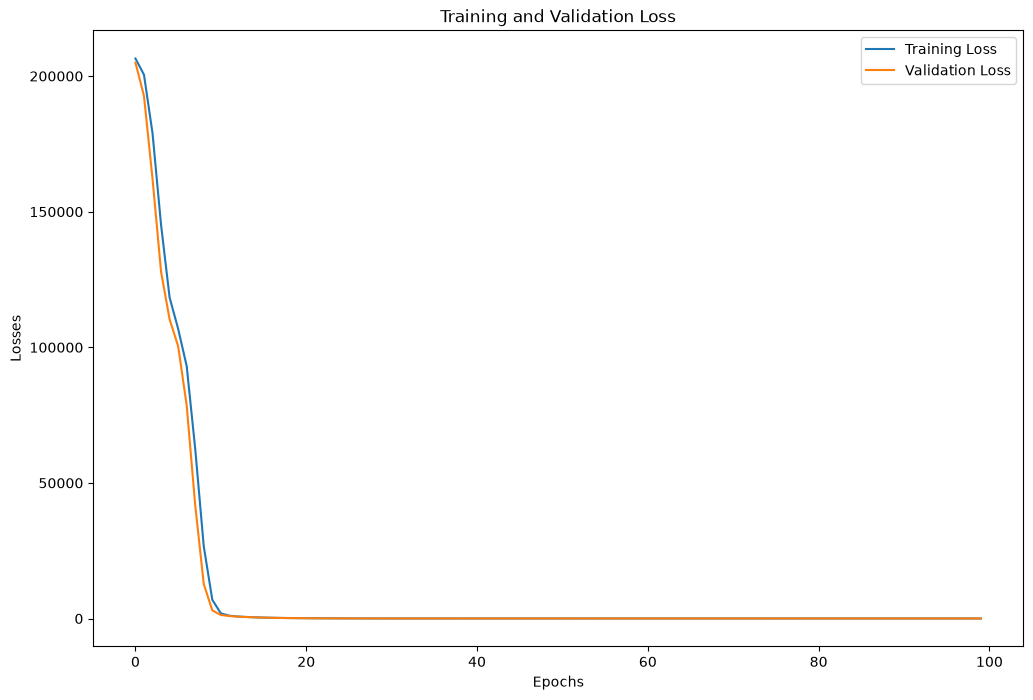

In [27]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({'Training Loss': train_losses, 'Validation Loss': val_losses})
plt.figure(figsize=(12, 8))
plt.plot(loss_df['Training Loss'], label='Training Loss')
plt.plot(loss_df['Validation Loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [28]:
#Loading the best model
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [29]:
# Evaluate our Model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print(f"Train MSE Loss: {train_mse_loss.item():.4f}")
print(f"Test MSE Loss: {test_mse_loss.item():.4f}")

Train MSE Loss: 19.5831
Test MSE Loss: 18.6137


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

print("R^2 Score for Train Set:", r2_score(y_train_tensor.numpy(), train_preds.numpy()))
print("R^2 Score for Test Set:", r2_score(y_test_tensor.numpy(), test_preds.numpy()))

R^2 Score for Train Set: 0.9330540895462036
R^2 Score for Test Set: 0.9349498748779297


In [ ]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=['Predicted_Values'])
actual_df = pd.DataFrame(y_test_tensor.numpy(), columns=['Actual_Values'])

pd.concat([actual_df, predicted_df], axis=1)

,Actual_Values,Predicted_Values
0,433.269989,435.928589
1,438.160004,437.338593
2,458.420013,461.189423
3,480.820007,475.738678
4,441.410004,435.962860
...,...,...
1909,456.700012,451.425446
1910,438.040009,432.240143
1911,467.799988,467.555328
1912,437.140015,431.679840


In [32]:
import joblib
torch.save(model.state_dict(), "gridsync_model.pth")
joblib.dump(scaler, "scaler.pkl")
print("✅ All artifacts exported")

✅ All artifacts exported
